In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/customer_ml_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (4587, 19)


In [3]:
df.head()

,customer_id,age,city,plan_type,signup_date,tenure_days,total_orders,total_revenue,average_order_value,last_order_date,days_since_last_order,total_payments,failed_payments,payment_failure_rate,total_tickets,avg_resolution_time,avg_satisfaction_score,churn,has_previous_order
0,C00001,19,Chennai,Basic,2023-08-17,775,8,48220.34,6027.54,2025-08-04,57.0,8,2,25.00,0,0.00,0.0,0,1
1,C00002,26,Mumbai,Premium,2024-04-02,546,10,50582.30,5058.23,2025-08-01,60.0,7,2,28.57,1,18.00,2.0,1,1
2,C00003,55,Kolkata,Basic,2023-06-28,825,8,45449.04,5681.13,2025-06-26,96.0,6,1,16.67,2,27.50,3.0,1,1
3,C00004,23,Hyderabad,Basic,2023-03-03,942,13,55824.66,4294.20,2025-07-24,68.0,4,0,0.00,1,65.00,5.0,1,1
4,C00006,63,Kolkata,Basic,2024-02-12,596,5,29055.60,5811.12,2025-02-23,219.0,5,0,0.00,4,16.25,1.5,1,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4587 entries, 0 to 4586
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             4587 non-null   str    
 1   age                     4587 non-null   int64  
 2   city                    4587 non-null   str    
 3   plan_type               4587 non-null   str    
 4   signup_date             4587 non-null   str    
 5   tenure_days             4587 non-null   int64  
 6   total_orders            4587 non-null   int64  
 7   total_revenue           4587 non-null   float64
 8   average_order_value     4587 non-null   float64
 9   last_order_date         4225 non-null   str    
 10  days_since_last_order   4587 non-null   float64
 11  total_payments          4587 non-null   int64  
 12  failed_payments         4587 non-null   int64  
 13  payment_failure_rate    4587 non-null   float64
 14  total_tickets           4587 non-null   int64  
 15

In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customer_id                 0
age                         0
city                        0
plan_type                   0
signup_date                 0
tenure_days                 0
total_orders                0
total_revenue               0
average_order_value         0
last_order_date           362
days_since_last_order       0
total_payments              0
failed_payments             0
payment_failure_rate        0
total_tickets               0
avg_resolution_time         0
avg_satisfaction_score      0
churn                       0
has_previous_order          0
dtype: int64


In [6]:
df.describe()

,age,tenure_days,total_orders,total_revenue,average_order_value,days_since_last_order,total_payments,failed_payments,payment_failure_rate,total_tickets,avg_resolution_time,avg_satisfaction_score,churn,has_previous_order
count,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000,4587.000000
mean,41.508393,500.420972,6.600174,33945.693379,4738.997404,67.878788,5.793547,1.175714,18.153536,1.660562,26.084075,2.124929,0.710050,0.921081
std,13.943616,287.469006,4.573591,24654.879509,1929.553259,71.349552,4.594824,1.343717,21.553976,1.610076,21.402759,1.636573,0.453788,0.269641
min,18.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,250.000000,3.000000,13738.035000,4066.295000,15.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,41.000000,506.000000,6.000000,31178.870000,5037.010000,47.000000,5.000000,1.000000,13.330000,1.000000,27.670000,2.330000,1.000000,1.000000
75%,54.000000,749.000000,10.000000,50469.940000,5864.805000,99.000000,9.000000,2.000000,28.570000,3.000000,42.730000,3.400000,1.000000,1.000000
max,65.000000,1003.000000,25.000000,143714.560000,9980.680000,636.000000,18.000000,7.000000,100.000000,10.000000,72.000000,5.000000,1.000000,1.000000


In [7]:
churn_counts = df["churn"].value_counts()

print("Churn distribution:")
print(churn_counts)

print("\nChurn percentage:")
print(
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn distribution:
churn
1    3257
0    1330
Name: count, dtype: int64

Churn percentage:
churn
1    71.01
0    28.99
Name: proportion, dtype: float64


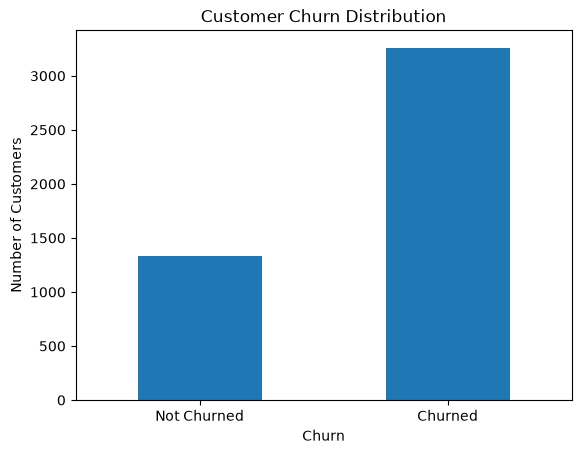

In [8]:
df["churn"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Churned", "Churned"],
    rotation=0
)
plt.show()

churn          0      1
plan_type              
Basic      28.22  71.78
Premium    30.29  69.71
Standard   28.46  71.54


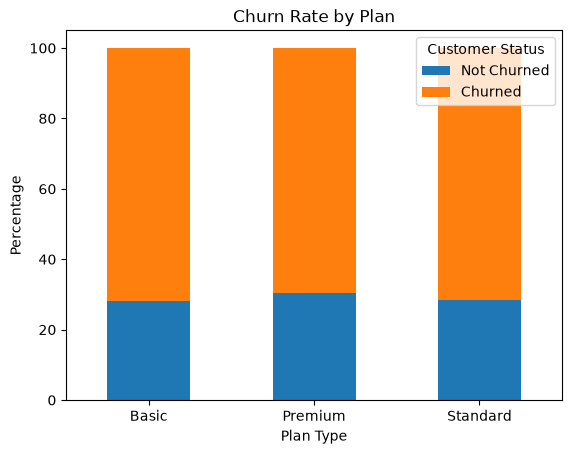

In [9]:
churn_by_plan = pd.crosstab(
    df["plan_type"],
    df["churn"],
    normalize="index"
) * 100

print(churn_by_plan.round(2))

churn_by_plan.plot(
    kind="bar",
    stacked=True
)

plt.title("Churn Rate by Plan")
plt.xlabel("Plan Type")
plt.ylabel("Percentage")
plt.legend(
    ["Not Churned", "Churned"],
    title="Customer Status"
)
plt.xticks(rotation=0)
plt.show()

churn          0      1
city                   
Bangalore  29.82  70.18
Chennai    29.88  70.12
Delhi      33.22  66.78
Hyderabad  29.78  70.22
Jaipur     28.68  71.32
Kolkata    25.00  75.00
Mumbai     27.98  72.02
Pune       27.84  72.16


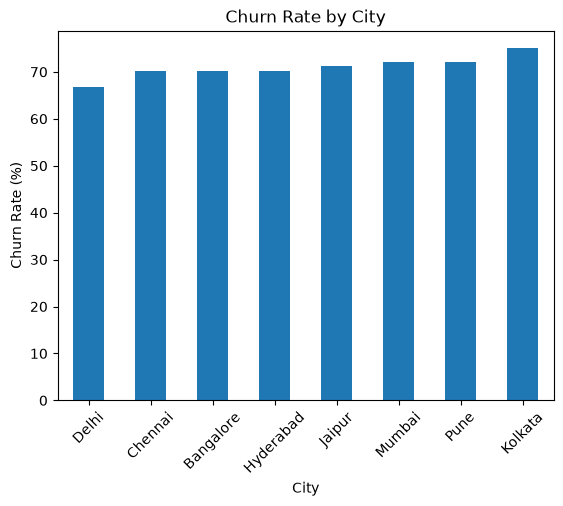

In [10]:
churn_by_city = pd.crosstab(
    df["city"],
    df["churn"],
    normalize="index"
) * 100

print(churn_by_city.round(2))

churn_by_city[1].sort_values().plot(
    kind="bar"
)

plt.title("Churn Rate by City")
plt.xlabel("City")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [11]:
features_to_compare = [
    "total_orders",
    "total_revenue",
    "average_order_value",
    "total_payments",
    "failed_payments",
    "payment_failure_rate",
    "total_tickets",
    "avg_resolution_time",
    "avg_satisfaction_score",
    "tenure_days",
    "days_since_last_order"
]

df.groupby("churn")[features_to_compare].mean().round(2)

,total_orders,total_revenue,average_order_value,total_payments,failed_payments,payment_failure_rate,total_tickets,avg_resolution_time,avg_satisfaction_score,tenure_days,days_since_last_order
churn,,,,,,,,,,,
0,5.98,30814.99,4696.06,5.28,1.09,18.29,1.53,25.13,2.02,450.35,60.71
1,6.85,35224.12,4756.53,6.00,1.21,18.10,1.71,26.47,2.17,520.87,70.81


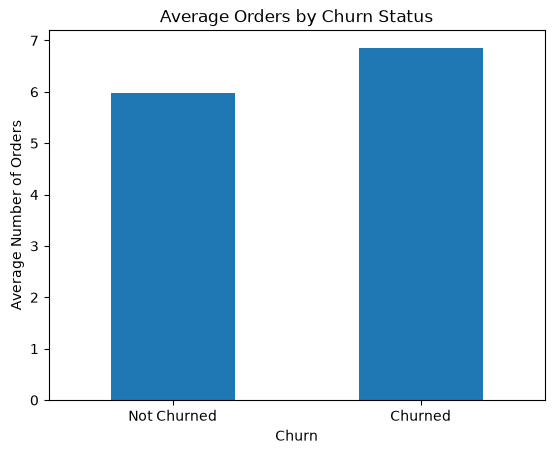

In [12]:
df.groupby("churn")["total_orders"].mean().plot(
    kind="bar"
)

plt.title("Average Orders by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Number of Orders")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Churned", "Churned"],
    rotation=0
)
plt.show()

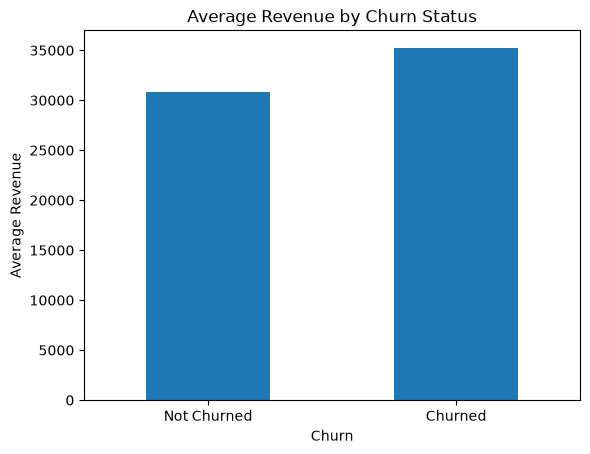

In [13]:
df.groupby("churn")["total_revenue"].mean().plot(
    kind="bar"
)

plt.title("Average Revenue by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Revenue")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Churned", "Churned"],
    rotation=0
)
plt.show()

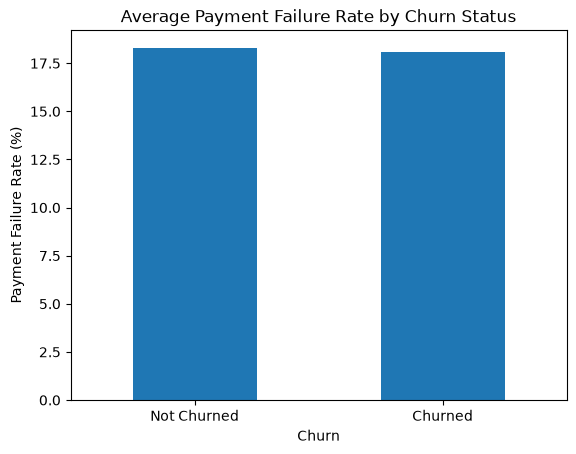

In [14]:
df.groupby("churn")["payment_failure_rate"].mean().plot(
    kind="bar"
)

plt.title("Average Payment Failure Rate by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Payment Failure Rate (%)")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Churned", "Churned"],
    rotation=0
)
plt.show()

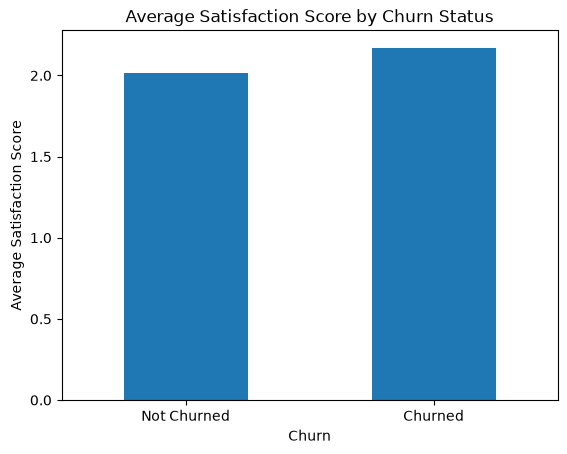

In [15]:
df.groupby("churn")["avg_satisfaction_score"].mean().plot(
    kind="bar"
)

plt.title("Average Satisfaction Score by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Satisfaction Score")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Churned", "Churned"],
    rotation=0
)
plt.show()

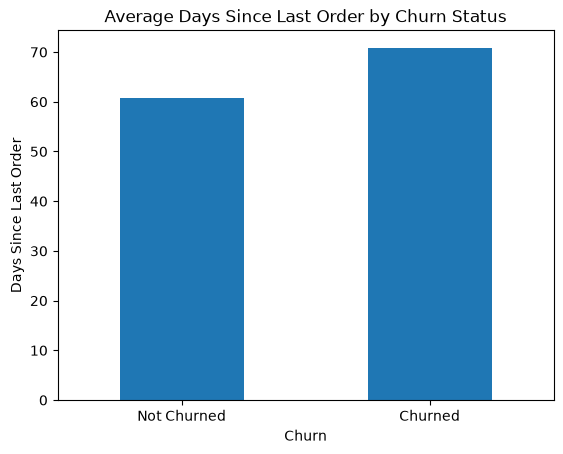

In [16]:
df.groupby("churn")["days_since_last_order"].mean().plot(
    kind="bar"
)

plt.title("Average Days Since Last Order by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Days Since Last Order")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Churned", "Churned"],
    rotation=0
)
plt.show()

In [17]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation["churn"].sort_values(ascending=False))

churn                     1.000000
tenure_days               0.111314
total_orders              0.086492
total_revenue             0.081153
total_payments            0.071366
days_since_last_order     0.064221
total_tickets             0.050601
avg_satisfaction_score    0.041953
failed_payments           0.041017
avg_resolution_time       0.028515
has_previous_order        0.014325
average_order_value       0.014221
age                       0.008380
payment_failure_rate     -0.004056
Name: churn, dtype: float64


In [18]:
churn_correlations = (
    correlation["churn"]
    .drop("churn")
    .sort_values(key=abs, ascending=False)
)

print("Features most strongly associated with churn:")
print(churn_correlations)

Features most strongly associated with churn:
tenure_days               0.111314
total_orders              0.086492
total_revenue             0.081153
total_payments            0.071366
days_since_last_order     0.064221
total_tickets             0.050601
avg_satisfaction_score    0.041953
failed_payments           0.041017
avg_resolution_time       0.028515
has_previous_order        0.014325
average_order_value       0.014221
age                       0.008380
payment_failure_rate     -0.004056
Name: churn, dtype: float64


In [19]:
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Duplicate customer IDs: 0


In [20]:
print("========== EDA SUMMARY ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nChurn counts:")
print(df["churn"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate customer IDs:")
print(df["customer_id"].duplicated().sum())

print("\n=================================")

========== EDA SUMMARY ==========
Rows: 4587
Columns: 19

Churn counts:
churn
1    3257
0    1330
Name: count, dtype: int64

Missing values:
customer_id                 0
age                         0
city                        0
plan_type                   0
signup_date                 0
tenure_days                 0
total_orders                0
total_revenue               0
average_order_value         0
last_order_date           362
days_since_last_order       0
total_payments              0
failed_payments             0
payment_failure_rate        0
total_tickets               0
avg_resolution_time         0
avg_satisfaction_score      0
churn                       0
has_previous_order          0
dtype: int64

Duplicate customer IDs:
0

